[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/02-transformer-architecture.ipynb)

# Transformer Architecture: The Foundation of Modern AI

**ELMED219 / BMED365 - Lab 3**

Last updated:<br>
2026-01-02, A. Lundervold

---

## Learning Objectives

After this notebook, you should be able to:
- Understand the self-attention mechanism
- Visualize how transformers process text
- Connect the architecture to practical use in healthcare

## Contents

1. [Environment Setup](#1-environment-setup)
2. [What is Attention?](#2-what-is-attention)
3. [Self-Attention in Practice](#3-self-attention-in-practice)
4. [Multi-Head Attention](#4-multi-head-attention)
5. [The Transformer Block](#5-the-transformer-block)
6. [Practical Significance for Healthcare](#6-practical-significance-for-healthcare)

---

## 1. Environment Setup

The code works both locally and in Google Colab.

In [11]:
import sys
import os

# Check if we're running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
    # Install necessary packages
    %pip install seaborn torch --quiet
else:
    print("Running in local environment")

# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch for transformer demonstration
try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
    print(f"PyTorch version: {torch.__version__}")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not available - some examples will not run")

print("Environment is configured and ready!")

Running in local environment
PyTorch version: 2.6.0
Environment is configured and ready!


---

## 2. What is Attention?

**Attention** is a mechanism that allows the model to focus on relevant parts of the input sequence when processing each element.

### The Intuition

Imagine you're reading the sentence:

> "The patient has severe diabetes, and **she** needs insulin treatment."

To understand who "she" refers to, you need to look back at "the patient". This is essentially what attention does - it allows the model to "look back" and connect relevant parts of the text.

### Mathematical Foundation

Attention is calculated with three components:
- **Query (Q)**: What we're looking for
- **Key (K)**: What each element "offers"
- **Value (V)**: The content that is returned

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

---

## 3. Self-Attention in Practice

Let's implement a simplified version of attention to understand how it works.

In [12]:
def simple_attention(query, keys, values):
    """
    Simplified attention mechanism.
    
    Args:
        query: Vector we're searching with
        keys: Matrix with keys to compare against
        values: Matrix with values to return
    
    Returns:
        output: Weighted sum of values
        weights: Attention weights
    """
    # Calculate similarity between query and keys (dot product)
    scores = np.dot(query, keys.T)
    
    # Normalize with softmax to get probabilities
    weights = np.exp(scores) / np.sum(np.exp(scores))
    
    # Weighted sum of values
    output = np.dot(weights, values)
    
    return output, weights

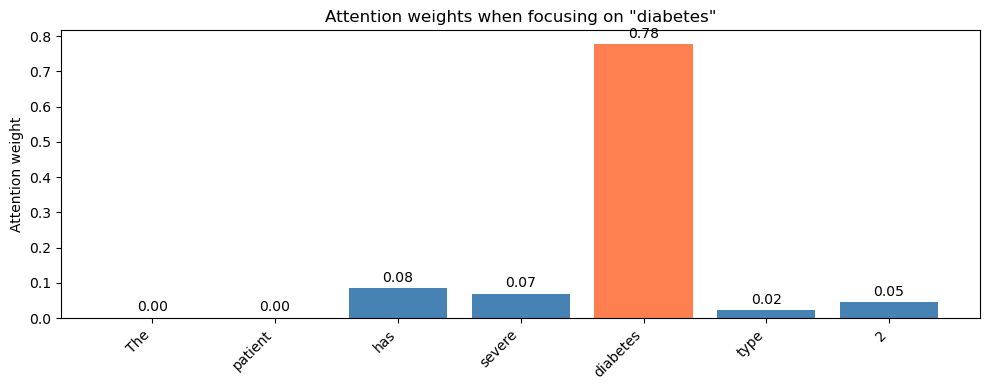


Highest attention: 'diabetes'
Second highest: 'has'


In [13]:
# Example: Medical sentence
words = ["The", "patient", "has", "severe", "diabetes", "type", "2"]

# Simulate word embeddings (in practice these would come from a trained model)
np.random.seed(42)  # For reproducibility
embedding_dim = 4
word_embeddings = np.random.randn(len(words), embedding_dim)

# Let's find attention for the word "diabetes" (index 4)
query_idx = 4
query = word_embeddings[query_idx]

# Calculate attention
output, attention_weights = simple_attention(query, word_embeddings, word_embeddings)

# Visualize attention weights
plt.figure(figsize=(10, 4))
colors = ['steelblue' if i != query_idx else 'coral' for i in range(len(words))]
bars = plt.bar(words, attention_weights, color=colors)
plt.title(f'Attention weights when focusing on "{words[query_idx]}"')
plt.ylabel('Attention weight')
plt.xticks(rotation=45, ha='right')

# Add values on the bars
for bar, weight in zip(bars, attention_weights):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{weight:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nHighest attention: '{words[np.argmax(attention_weights)]}'")
print(f"Second highest: '{words[np.argsort(attention_weights)[-2]]}'")

### Visualization of the Attention Matrix

Let's look at the full attention matrix - how each word "sees" all other words.

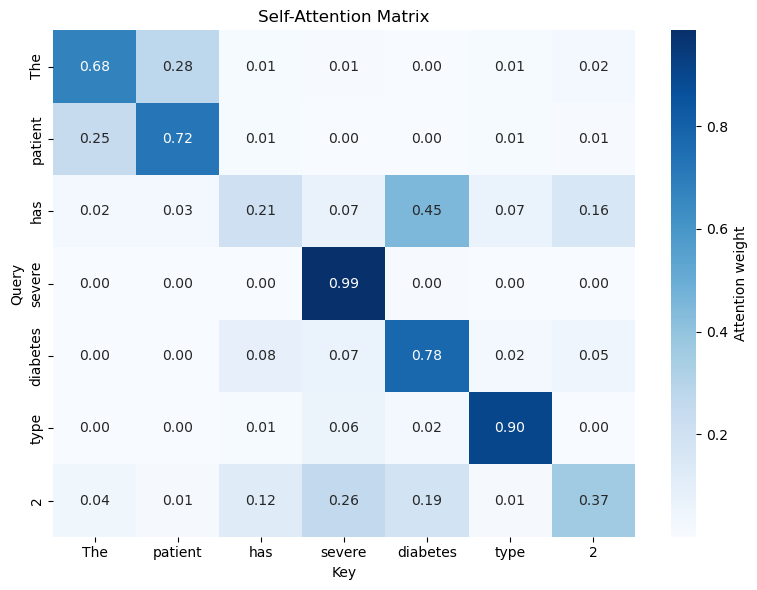

In [14]:
# Calculate full attention matrix
def compute_attention_matrix(embeddings):
    """Calculate attention between all pairs of words."""
    n = len(embeddings)
    attention_matrix = np.zeros((n, n))
    
    for i in range(n):
        _, weights = simple_attention(embeddings[i], embeddings, embeddings)
        attention_matrix[i] = weights
    
    return attention_matrix

attention_matrix = compute_attention_matrix(word_embeddings)

# Visualize as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(attention_matrix, 
            xticklabels=words, 
            yticklabels=words,
            annot=True, 
            fmt='.2f',
            cmap='Blues',
            cbar_kws={'label': 'Attention weight'})
plt.title('Self-Attention Matrix')
plt.xlabel('Key')
plt.ylabel('Query')
plt.tight_layout()
plt.show()

### Reflection

> **Think about**: In a real medical context, which word pairs would you expect high attention between?
> 
> For example: "patient" ↔ "diagnosis", "medication" ↔ "dose", "symptom" ↔ "treatment"

---

## 4. Multi-Head Attention

In practice, transformers use **multiple attention "heads"** that can focus on different aspects of the input simultaneously:

- **Head 1**: Grammatical relations (subject-verb)
- **Head 2**: Semantic connections (symptom-diagnosis)
- **Head 3**: Medical terminology (generic name-brand name)
- **Head 4**: Temporal relations (before-after treatment)

This gives the model richer representations.

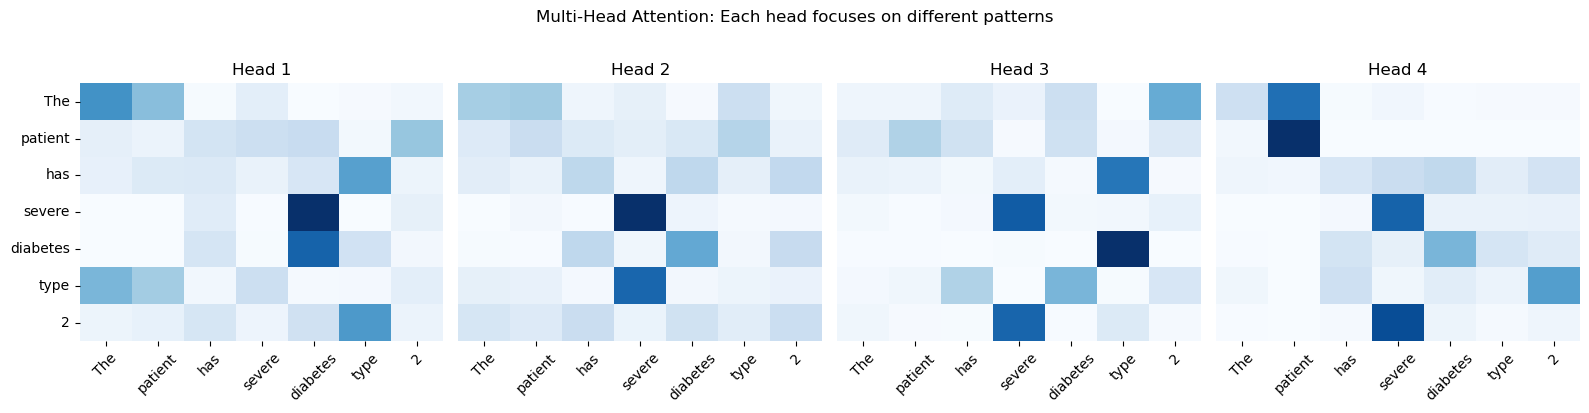

In [15]:
def multi_head_attention_demo(embeddings, n_heads=4):
    """
    Demonstrate multi-head attention with different random projections.
    """
    n_words, d_model = embeddings.shape
    d_head = d_model  # Simplified: same dimension per head
    
    fig, axes = plt.subplots(1, n_heads, figsize=(16, 4))
    
    for h in range(n_heads):
        # Simulate different projections for each head
        np.random.seed(h * 100)
        W_q = np.random.randn(d_model, d_head) * 0.5
        W_k = np.random.randn(d_model, d_head) * 0.5
        
        # Transform embeddings
        Q = embeddings @ W_q
        K = embeddings @ W_k
        
        # Calculate attention for this head
        scores = Q @ K.T
        attention = np.exp(scores) / np.exp(scores).sum(axis=1, keepdims=True)
        
        # Visualize
        sns.heatmap(attention, ax=axes[h], cmap='Blues', 
                    xticklabels=words, yticklabels=words if h == 0 else False,
                    cbar=False)
        axes[h].set_title(f'Head {h+1}')
        axes[h].tick_params(axis='x', rotation=45)
    
    plt.suptitle('Multi-Head Attention: Each head focuses on different patterns', y=1.02)
    plt.tight_layout()
    plt.show()

multi_head_attention_demo(word_embeddings)

---

## 5. The Transformer Block

A complete transformer block consists of:

1. **Multi-Head Self-Attention**
2. **Add & Normalize** (residual connection + layer norm)
3. **Feed-Forward Network**
4. **Add & Normalize**

```
Input
  │
  ├──────────────────┐
  ↓                  │
Multi-Head Attention │
  ↓                  │
  + ←────────────────┘  (Residual Connection)
  ↓
Layer Norm
  │
  ├──────────────────┐
  ↓                  │
Feed-Forward Network │
  ↓                  │
  + ←────────────────┘  (Residual Connection)
  ↓
Layer Norm
  ↓
Output
```

In [16]:
if TORCH_AVAILABLE:
    class SimpleTransformerBlock(nn.Module):
        """Simplified transformer block for demonstration."""
        
        def __init__(self, d_model=512, n_heads=8, d_ff=2048):
            super().__init__()
            self.attention = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
            self.norm1 = nn.LayerNorm(d_model)
            self.norm2 = nn.LayerNorm(d_model)
            self.feed_forward = nn.Sequential(
                nn.Linear(d_model, d_ff),
                nn.ReLU(),
                nn.Linear(d_ff, d_model)
            )
        
        def forward(self, x):
            # Self-attention with residual connection
            attn_output, _ = self.attention(x, x, x)
            x = self.norm1(x + attn_output)
            
            # Feed-forward with residual connection
            ff_output = self.feed_forward(x)
            x = self.norm2(x + ff_output)
            
            return x

    # Demonstrate
    model = SimpleTransformerBlock(d_model=512, n_heads=8)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Transformer block created with {n_params:,} parameters")
    print(f"\nArchitecture:\n{model}")
else:
    print("PyTorch not available - skipping transformer block demo")

Transformer block created with 3,152,384 parameters

Architecture:
SimpleTransformerBlock(
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (feed_forward): Sequential(
    (0): Linear(in_features=512, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=512, bias=True)
  )
)


### Scaling

Modern language models stack many such blocks:

| Model | Blocks | Attention Heads | Parameters |
|-------|--------|-----------------|------------|
| BERT-base | 12 | 12 | 110M |
| GPT-2 | 12 | 12 | 117M |
| GPT-3 | 96 | 96 | 175B |
| GPT-4 | ~120? | ~96? | ~1.7T? |

---

## 6. Practical Significance for Healthcare

The transformer architecture enables many important applications:

### 1. Clinical Note Summarization
Attention allows the model to identify and focus on the most important parts of long patient records.

### 2. Diagnostic Support
By connecting symptoms to possible diagnoses through attention patterns.

### 3. Drug Interactions
Detect potential drug interactions by relating medications to each other.

### 4. Patient Communication
Explain medical terms in an understandable way by understanding context.

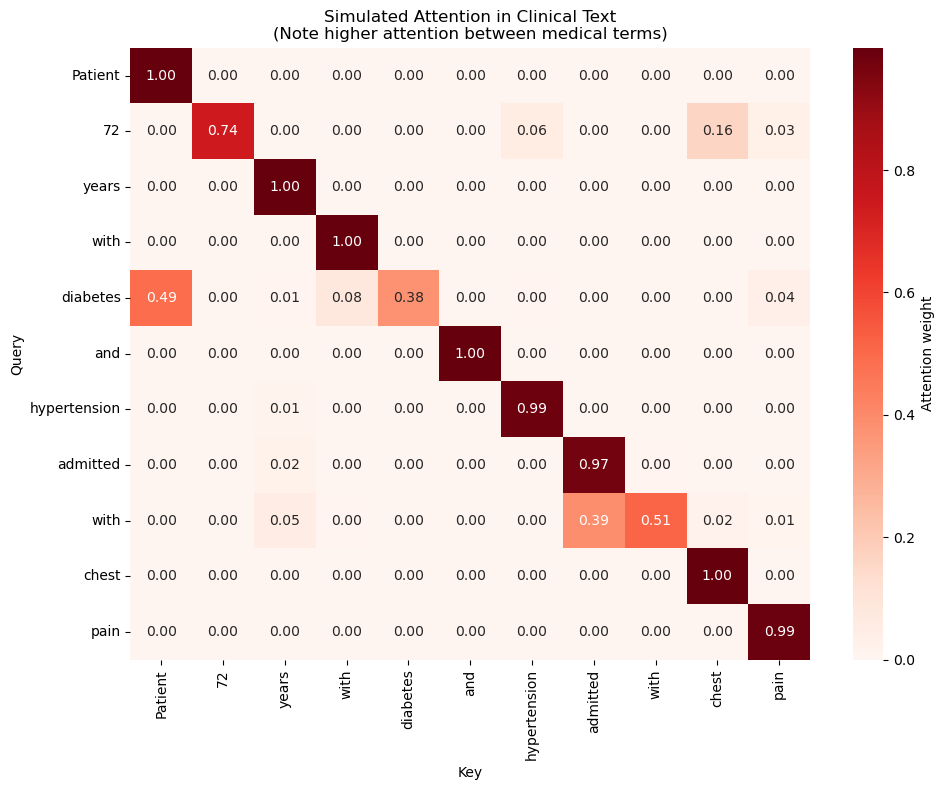

In [17]:
# Example: Simulate attention in a clinical context
clinical_text = ["Patient", "72", "years", "with", "diabetes", "and", "hypertension", 
                 "admitted", "with", "chest", "pain"]

# Simulate that the model has learned meaningful embeddings
# (in practice this would be from training on millions of documents)
np.random.seed(123)
clinical_embeddings = np.random.randn(len(clinical_text), 8)

# Adjust embeddings to simulate meaningful relations
# Symptom-related words (diabetes, hypertension, chest pain) should have high attention to each other
symptom_indices = [4, 6, 10]  # diabetes, hypertension, chest pain
for i in symptom_indices:
    for j in symptom_indices:
        if i != j:
            clinical_embeddings[i] += 0.3 * clinical_embeddings[j]

# Calculate attention matrix
clinical_attention = compute_attention_matrix(clinical_embeddings)

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(clinical_attention, 
            xticklabels=clinical_text, 
            yticklabels=clinical_text,
            annot=True, 
            fmt='.2f',
            cmap='Reds',
            cbar_kws={'label': 'Attention weight'})
plt.title('Simulated Attention in Clinical Text\n(Note higher attention between medical terms)')
plt.xlabel('Key')
plt.ylabel('Query')
plt.tight_layout()
plt.show()

---

## Summary

### Key Points

1. **Attention** allows the model to focus on relevant parts of the input
2. **Self-attention** calculates relations between all words in a sequence
3. **Multi-head attention** captures different types of relations simultaneously
4. **Transformer blocks** combine attention with feed-forward networks
5. **Scaling** this architecture gives us today's powerful language models

### Reflection Questions

1. Why do you think the attention mechanism is particularly useful for medical texts?
2. What challenges can arise when using attention on very long documents?
3. How can visualization of attention contribute to explainable AI in medicine?

---

*Next notebook: [03 - LLM Fundamentals](03-llm-fundamentals.ipynb)*